In [1]:
import pandas as pd
import os

In [2]:
BASE_PATH = 'dataset'
RESULTS_FOLDER = os.path.join(BASE_PATH, 'results')

In [3]:
rf_imp = pd.read_csv(
    os.path.join(RESULTS_FOLDER, 'random_forest_feature_importance.csv')
)

xgb_imp = pd.read_csv(
    os.path.join(RESULTS_FOLDER, 'xgboost_feature_importance.csv')
)

In [4]:
rf_imp = rf_imp.rename(columns={'importance': 'rf_importance'})
xgb_imp = xgb_imp.rename(columns={'importance': 'xgb_importance'})

In [5]:
feature_importance = rf_imp.merge(
    xgb_imp,
    on='feature'
)

In [6]:
feature_importance['avg_importance'] = (
    feature_importance['rf_importance'] +
    feature_importance['xgb_importance']
) / 2

In [7]:
feature_importance = feature_importance.sort_values(
    by='avg_importance',
    ascending=False
)

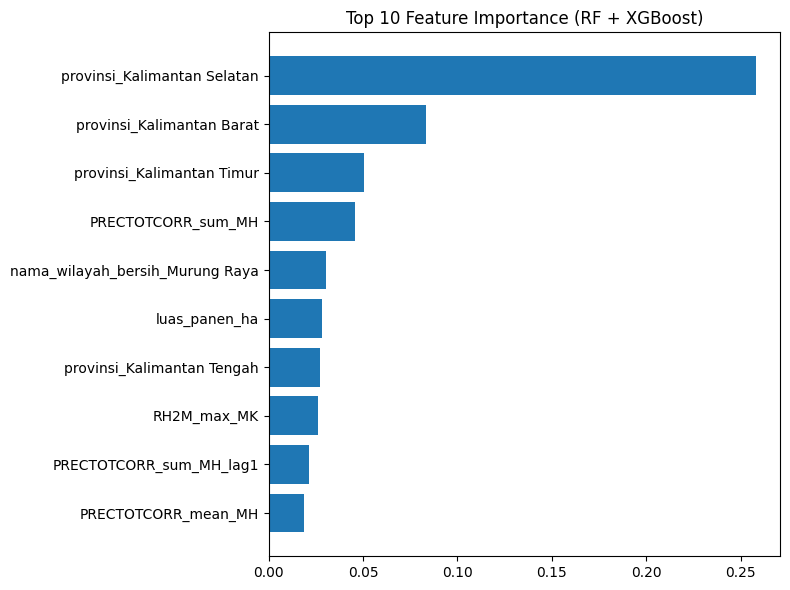

In [8]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(8,6))
plt.barh(top10['feature'], top10['avg_importance'])
plt.title('Top 10 Feature Importance (RF + XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()